# 4.0 LDAClassifier — 템플릿 공격

## 이 노트북이 답하는 질문

**타겟과 같은 장비를 미리 만질 수 있다면** 얼마나 강해지는가?

CPA(3.0)는 "해밍 가중치로 샐 것" 이라는 **가정**을 세우고 상관을 잰다. 가정이 틀리면 약해진다.
프로파일링 공격은 가정 대신 **측정**한다 — 키를 아는 장비에서 중간값별 누설 분포를 학습해
두고, 공격 대상 파형이 어느 분포에서 나왔는지 따진다.

`scalib.modeling.LDAClassifier` 는 그 학습·판정을 맡는다.

| | |
|---|---|
| 학습 | `/profiling` (랜덤 키·랜덤 평문 100,000장) |
| 공격 | `/attack` (고정 키 10,000장) |
| 하드웨어 | 불필요. 단, `1.0.SNR` 을 먼저 실행해야 한다 |

## LDA 가 하는 일

파형에서 POI 를 골라도 차원이 수십이다. 클래스가 256개인데 차원이 높으면 학습이 불안정하다.

LDA(선형 판별 분석)는 **클래스가 가장 잘 갈리는 방향** $p$ 개를 찾아 그 축으로 투영한다.
클래스 간 분산 $S_b$ 는 키우고 클래스 내 분산 $S_w$ 는 줄이는 방향이다. 투영 뒤에는
클래스마다 가우시안 하나로 모델링하고, 새 파형이 오면 각 클래스의 확률을 계산한다.

$$ \Pr[\ v = j \mid \mathbf{l}\ ] \ \propto\ \mathcal{N}\big(\mathbf{W}^\top \mathbf{l};\ \mu_j,\ \Sigma\big) $$

출력은 **확률**이다. CPA 의 상관계수와 달리 그대로 곱하고 합쳐 쓸 수 있어,
SASCA(5.0)나 키랭크(6.0)로 이어진다.

## 진행 순서

| 단계 | 내용 |
|:----:|------|
| 1 | POI 적재 · 프로파일링 데이터 읽기 |
| 2 | `LDAClassifier` 학습 |
| 3 | 공격 — 한 장으로 키 한 바이트 맞히기 |
| 4 | 여러 장을 합치면 (로그확률 누적) |
| 5 | 투영 차원 `p` 의 영향 |
| 6 | 학습 장수의 영향 |

In [1]:
import sys
import numpy as np
import matplotlib
import matplotlib.pyplot as plt

matplotlib.rcParams["font.family"] = "NanumGothic"
matplotlib.rcParams["axes.unicode_minus"] = False

# 공용 정의(AES 상수·데이터셋 로더)는 scalib_common.py 한 곳에만 둔다.
# 노트북마다 복사하면 값을 고칠 곳이 10군데가 되기 때문이다.
sys.path.insert(0, ".")
from scalib_common import SBOX, HW, AES_BLOCK, sbox_out, load_group, dataset_summary

import scalib
print("SCALib :", scalib.__version__)
print()
print(dataset_summary())

SCALib : 0.6.4

측정 조건
  created      2026-08-07T00:34:27
  cipher       AES-128-ECB (tiny-AES-c)
  platform     CW308_STM32F3
  ns           33172
  adc_mul      4
  adc_freq     29537976.0
  clk_hz       7384494.0
  gain_db      25.091743119266056
  trace_scale  32768.0

그룹
  /attack      10000 장 x 33172 샘플   키=fixed 평문=random
  /explore      5000 장 x 33172 샘플   키=random 평문=random
  /profiling  100000 장 x 33172 샘플   키=? 평문=?
  /tvla_fk      1000 장 x 33172 샘플   키=fixed 평문=fixed
  /tvla_rk      1000 장 x 33172 샘플   키=random 평문=fixed


In [2]:
from pathlib import Path

POI_PATH = Path("nb_output/poi.npz")
if not POI_PATH.is_file():
    raise FileNotFoundError(
        "nb_output/poi.npz 가 없다. 1.0.SNR.ipynb 를 먼저 실행한다.\n"
        "프로파일링은 파형 전체가 아니라 누설 지점 주변만 쓰기 때문이다.")
pz = np.load(POI_PATH)
poi, windows = pz["poi"], pz["windows"]

# 16바이트의 창을 모두 덮는 연속 구간을 한 번에 읽는다.
# 흩어진 인덱스로 HDF5 를 읽으면 느리므로, 넓게 읽고 메모리에서 자른다.
LO, HI = int(windows.min()), int(windows.max()) + 1
print("POI 구간 [%d, %d) — %d 샘플, 바이트당 창 %d 샘플" % (LO, HI, HI - LO, windows.shape[1]))

POI 구간 [6025, 6918) — 893 샘플, 바이트당 창 41 샘플


In [3]:
BYTE = 0                      # 이 노트북은 바이트 하나에 집중한다 (16개 동시는 4.1)
N_PROF = 100000

prof = load_group("profiling", n=N_PROF, samples=slice(LO, HI))
atk = load_group("attack", samples=slice(LO, HI))
TRUE_KEY = np.array(atk["attrs"]["fixed_key"], dtype=np.uint8)

# 창 인덱스를 잘라 읽은 구간 기준으로 옮긴다.
w = windows[BYTE] - LO

# 학습 라벨: 프로파일링 장비는 키를 아니까 중간값을 그대로 계산할 수 있다.
x_prof = sbox_out(prof["p"], prof["k"])[:, BYTE].astype(np.uint16)

print("프로파일링:", prof["t"].shape, " 창 %d 샘플" % len(w))
print("클래스당 표본: 평균 %.1f 장 (최소 %d)"
      % (N_PROF / 256, np.bincount(x_prof, minlength=256).min()))
print("공격 대상  :", atk["t"].shape, " 정답 키[%d] = 0x%02x" % (BYTE, TRUE_KEY[BYTE]))

프로파일링: (100000, 893)  창 41 샘플
클래스당 표본: 평균 390.6 장 (최소 338)
공격 대상  : (10000, 893)  정답 키[0] = 0x2f


---
## 1. 학습

| 단계 | 코드 |
|:----:|------|
| 생성 | `lda = LDAClassifier(nc=256, p=8)` |
| 누적 | `lda.fit_u(traces, x)` — 여러 번 나눠 부를 수 있다 |
| 완료 | `lda.solve()` — 투영 행렬과 분포를 실제로 계산한다 |
| 판정 | `lda.predict_proba(traces)` → `(n, nc)` |

`p` 는 투영 차원이다. 너무 작으면 정보를 버리고, 너무 크면 학습이 불안정해진다.

> **`LDAClassifier` 의 라벨은 1차원이다.** `SNR`·`Cpa`·`MultiLDA` 는 2차원인데 여기만 다르다.

> **라벨 shape 규약이 API 마다 다르다.** 문서에 정리되어 있지 않고 실행해 봐야 알 수 있어
> 여기 적어 둔다. 틀리면 `ValueError: The classes array has N dimensions` 가 난다.
>
> | API | 라벨 shape | dtype |
> |-----|-----------|-------|
> | `Ttest` | `(n,)` | `uint16` |
> | `SNR`, `Cpa`, `MultiLDA` | `(n, nv)` | `uint16` |
> | `LDAClassifier` | `(n,)` | `uint16` |
> | `RLDAClassifier` | `(n, nv)` | `uint64` |
> | `RLDAInformationEstimator` | `(n,)` | `uint64` |
>
> 파형(`traces`)은 어디서나 `(n, ns)` `int16` 이다.

In [4]:
from scalib.modeling import LDAClassifier
import time

P_DIM = 8
t0 = time.time()
lda = LDAClassifier(nc=256, p=P_DIM)
lda.fit_u(np.ascontiguousarray(prof["t"][:, w]), x_prof)   # 라벨 1차원
lda.solve()
print("학습 %.1f 초 (%d장 x %d샘플, p=%d)" % (time.time() - t0, N_PROF, len(w), P_DIM))

학습 0.1 초 (100000장 x 41샘플, p=8)


---
## 2. 공격 — 파형 한 장으로 얼마나 알 수 있나

공격 파형의 평문은 알고 있다. 모델이 주는 것은 **SBox 출력 $v$ 의 확률**이므로,
키 후보 $g$ 의 확률로 옮기려면 $v = \mathrm{SBOX}[p \oplus g]$ 를 되짚으면 된다.

In [5]:
proba = lda.predict_proba(np.ascontiguousarray(atk["t"][:, w]))   # (n, 256)
p_atk = atk["p"][:, BYTE]

# 각 트레이스에서 정답 중간값의 확률과 순위
v_true = SBOX[np.bitwise_xor(p_atk, TRUE_KEY[BYTE])]
rank_true = (proba > proba[np.arange(len(proba)), v_true][:, None]).sum(axis=1)

print("파형 한 장 기준")
print("  정답 중간값의 평균 확률 : %.4f  (무작위면 %.4f)" % (proba[np.arange(len(proba)), v_true].mean(), 1/256))
print("  정답이 1등인 비율       : %.1f%%" % (100 * (rank_true == 0).mean()))
print("  정답이 상위 10위 안 비율: %.1f%%" % (100 * (rank_true < 10).mean()))
print("  정답의 평균 순위        : %.1f / 256" % rank_true.mean())

파형 한 장 기준
  정답 중간값의 평균 확률 : 0.1354  (무작위면 0.0039)
  정답이 1등인 비율       : 23.9%
  정답이 상위 10위 안 비율: 75.2%
  정답의 평균 순위        : 7.5 / 256


### 여러 장을 합치기

한 장으로는 부족해도 파형이 여러 장이면 정보가 쌓인다. 트레이스는 서로 독립이므로
확률을 곱하면 되고, 수치 안정을 위해 **로그를 더한다.**

$$ \log \Pr[k = g] \ =\ \sum_i \log \Pr[\ v = \mathrm{SBOX}[p_i \oplus g]\ \mid\ \mathbf{l}_i\ ] $$

In [6]:
def key_logprob(proba, plaintexts, n_use):
    """앞의 n_use 장을 합쳐 키 후보 256개의 로그확률을 낸다."""
    lp = np.log(np.maximum(proba[:n_use], 1e-300))
    guesses = SBOX[np.bitwise_xor(plaintexts[:n_use, None], np.arange(256, dtype=np.uint8)[None, :])]
    return np.take_along_axis(lp, guesses, axis=1).sum(axis=0)     # (256,)

print("사용 장수   복구 키   정답   정답 순위")
for m in (1, 2, 5, 10, 20, 50, 100):
    sc = key_logprob(proba, p_atk, m)
    guess = int(sc.argmax())
    rank = int((sc > sc[TRUE_KEY[BYTE]]).sum())
    print("   %5d      0x%02x    0x%02x      %3d %s"
          % (m, guess, TRUE_KEY[BYTE], rank, "★" if guess == TRUE_KEY[BYTE] else ""))

사용 장수   복구 키   정답   정답 순위
       1      0x2f    0x2f        0 ★
       2      0x2f    0x2f        0 ★
       5      0x2f    0x2f        0 ★
      10      0x2f    0x2f        0 ★
      20      0x2f    0x2f        0 ★
      50      0x2f    0x2f        0 ★
     100      0x2f    0x2f        0 ★


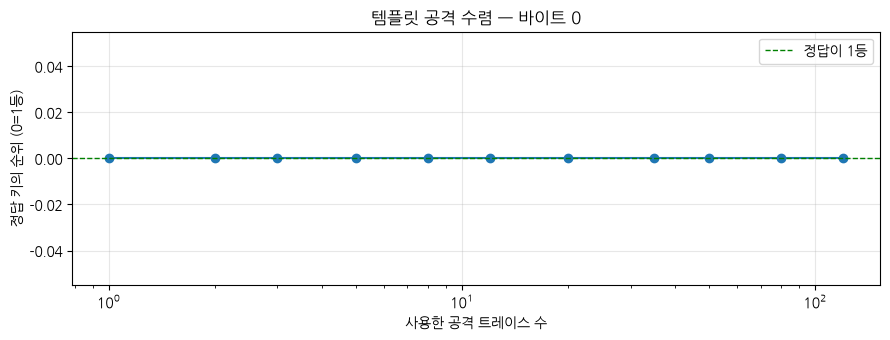

In [7]:
ms = [1, 2, 3, 5, 8, 12, 20, 35, 50, 80, 120]
ranks = [int((key_logprob(proba, p_atk, m) > key_logprob(proba, p_atk, m)[TRUE_KEY[BYTE]]).sum())
         for m in ms]
plt.figure(figsize=(9, 3.5))
plt.plot(ms, ranks, "o-")
plt.axhline(0, color="g", ls="--", lw=1, label="정답이 1등")
plt.xscale("log"); plt.xlabel("사용한 공격 트레이스 수"); plt.ylabel("정답 키의 순위 (0=1등)")
plt.title("템플릿 공격 수렴 — 바이트 %d" % BYTE)
plt.legend(); plt.grid(True, alpha=0.3); plt.tight_layout(); plt.show()

---
## 3. 투영 차원 `p` 의 영향

`p` 를 바꿔 가며 "정답이 1등인 비율"(파형 한 장 기준)을 본다.

In [8]:
N_SUB = 30000       # 비교를 빨리 돌리기 위해 부분집합으로 학습한다
sub_t = np.ascontiguousarray(prof["t"][:N_SUB, w])
sub_x = x_prof[:N_SUB]
atk_t = np.ascontiguousarray(atk["t"][:2000, w])
v_true2 = v_true[:2000]

print(" p    학습(초)  정답 1등 비율   정답 평균확률")
for p_dim in (2, 4, 8, 16):
    t0 = time.time()
    m = LDAClassifier(nc=256, p=p_dim); m.fit_u(sub_t, sub_x); m.solve()
    dt = time.time() - t0
    pr = m.predict_proba(atk_t)
    top1 = (pr.argmax(axis=1) == v_true2).mean()
    print("%2d    %6.1f    %10.1f%%    %10.4f" % (p_dim, dt, 100 * top1,
                                                  pr[np.arange(len(pr)), v_true2].mean()))

 p    학습(초)  정답 1등 비율   정답 평균확률
 2       0.0          10.7%        0.0691
 4       0.0          19.9%        0.1165
 8       0.0          22.2%        0.1347
16       0.0          20.8%        0.1329


---
## 4. 학습 장수의 영향

클래스가 256개이므로 학습 장수가 적으면 클래스당 표본이 부족해 모델이 흔들린다.

In [9]:
print("학습 장수   클래스당 평균   정답 1등 비율")
for m_prof in (2560, 12800, 30000, 60000, N_PROF):
    mm = LDAClassifier(nc=256, p=P_DIM)
    mm.fit_u(np.ascontiguousarray(prof["t"][:m_prof, w]), x_prof[:m_prof])
    mm.solve()
    pr = mm.predict_proba(atk_t)
    print("  %6d       %7.1f        %8.1f%%"
          % (m_prof, m_prof / 256, 100 * (pr.argmax(axis=1) == v_true2).mean()))

학습 장수   클래스당 평균   정답 1등 비율
    2560          10.0            18.6%
   12800          50.0            20.7%
   30000         117.2            22.2%
   60000         234.4            22.8%
  100000         390.6            22.2%


---
## 5. 요약

| 항목 | 내용 |
|------|------|
| 목적 | 프로파일링으로 중간값의 **확률**을 얻고, 그것으로 키를 복구한다 |
| API | `LDAClassifier(nc, p)` → `fit_u(traces, x)` → `solve()` → `predict_proba(traces)` |
| `x` | `(n,)` `uint16` — **1차원**. `SNR`·`Cpa`·`MultiLDA` 와 다르다 |
| 출력 | `(n, nc)` 확률. 로그를 더해 여러 장을 합칠 수 있다 |
| CPA 와 차이 | 누설 모델을 **가정하지 않고 측정**한다. 대신 프로파일링 장비가 필요하다 |

### 실패 시 점검

1. `solve()` 를 부르지 않으면 `predict_proba` 가 실패한다.
2. 정답 확률이 1/256 근처에 머문다 → POI 가 틀렸거나 학습 장수가 부족하다.
3. `p` 가 클수록 항상 좋지는 않다. §3 표로 고른다.

다음: `4.1.MultiLDA.ipynb` — 16바이트를 한 번에.